In [ ]:
from sqlglot.optimizer.scope import build_scope
from sqlglot import parse_one
from sqlglot.optimizer.qualify import qualify
from sqlglot.lineage import lineage, GraphHTML
from sqlglot import exp
from lineage import LineageMap

sql = """
WITH cleaned_orders AS (
    SELECT
        o.order_id,
        o.customer_id,
        CAST(o.order_ts AS DATE) AS order_date,
        COALESCE(o.amount, 0) AS amount,
        o.status AS order_status
    FROM db.raw_orders o
    WHERE o.order_ts IS NOT NULL
),

valid_orders AS (
    SELECT
        order_id,
        customer_id,
        order_date,
        amount,
        order_status
    FROM cleaned_orders
    WHERE order_status IN ('paid', 'shipped', 'completed')
),

orders_with_payments AS (
    SELECT
        vo.order_id,
        vo.customer_id,
        vo.order_date,
        vo.amount,
        p.payment_status
    FROM valid_orders vo
    LEFT JOIN raw_payments p
        ON vo.order_id = p.order_id
),

paid_orders AS (
    SELECT
        order_id,
        customer_id,
        order_date,
        amount
    FROM orders_with_payments
    WHERE payment_status = 'success'
),

customer_aggregates AS (
    SELECT
        po.customer_id,
        COUNT(po.order_id) AS total_orders,
        SUM(po.amount) AS total_revenue,
        AVG(po.amount) AS avg_order_value,
        MIN(po.order_date) AS first_order_date,
        MAX(po.order_date) AS last_order_date
    FROM paid_orders po
    GROUP BY po.customer_id
),

customer_enriched AS (
    SELECT
        c.customer_id,
        c.customer_name,
        c.country,
        c.signup_date,
        ca.total_orders,
        ca.total_revenue,
        ca.avg_order_value,
        ca.first_order_date,
        ca.last_order_date,
        (CURRENT_DATE - ca.last_order_date) AS days_since_last_order
    FROM raw_customers c
    LEFT JOIN customer_aggregates ca
        ON c.customer_id = ca.customer_id
),

customer_segmented AS (
    SELECT
        ce.customer_id,
        ce.customer_name,
        ce.country,
        ce.signup_date,
        COALESCE(ce.total_orders, 0) AS total_orders,
        COALESCE(ce.total_revenue, 0) AS total_revenue,
        ce.avg_order_value,
        ce.first_order_date,
        ce.last_order_date,
        ce.days_since_last_order,
        CASE
            WHEN ce.total_revenue >= 10000 THEN 'VIP'
            WHEN ce.days_since_last_order > 180 THEN 'Churn Risk'
            WHEN ce.total_orders >= 5 THEN 'Regular'
            ELSE 'New'
        END AS customer_segment
    FROM customer_enriched ce
)

SELECT
        cs.customer_id,
    cs.customer_name,
    cs.country,
    cs.signup_date,
FROM customer_segmented cs
"""

ast_sql = qualify(parse_one(sql))
scopes_sql = build_scope(ast_sql)



In [ ]:
ast_sql.selects

In [ ]:
l = LineageMap()
l.parse_sql(sql)

In [ ]:
l.table_node_map

In [ ]:
create_table = """
CREATE TABLE persons (
    PersonID INT PRIMARY KEY,
    LastName VARCHAR(255) NOT NULL,
    FirstName VARCHAR(255),
    Address VARCHAR(255),
    City VARCHAR(255)
);
"""

ast_create=  qualify(parse_one(create_table))
l.extend_table("persons", create_table)

In [ ]:
create_table_orders = """
CREATE TABLE db.raw_orders (
    order_id INT PRIMARY KEY,
    customer_id INT NOT NULL REFERENCES persons(PersonID),
    OrderDate DATE NOT NULL,
    Quantity INT NOT NULL
);

"""

ast_create=  qualify(parse_one(create_table_orders))
l.extend_table("db.raw_orders", create_table_orders)

In [ ]:
l.visualize()

In [ ]:
l.tableNodeMap["cleaned_orders"]

In [ ]:
l.tableNodeMap["cleaned_orders"].sources["o"]

In [ ]:
l.tableNodeMap["db.raw_orders"].upstream[0].sources["o"] == n1

In [ ]:
scope1 = a

In [ ]:
from sqlglot.lineage import lineage
from IPython.display import HTML, display

In [ ]:
l.tableNodeMap['Scope_1'].scope.sources

In [ ]:
sql = """
SELECT employee_id, name, salary, department
FROM (
    SELECT employee_id, name, salary, department
    FROM (
        -- Level 3 (innermost): base filter
        SELECT employee_id, name, salary, department
        FROM employees
        WHERE salary > 50000
    ) AS high_paid
    -- Level 2: compare against aggregate from another subquery
    WHERE salary < (
        SELECT AVG(salary)
        FROM (
            SELECT salary
            FROM employees
            WHERE salary > 50000
        ) AS avg_base
    )
) AS filtered
-- Level 1 (outermost): final business filter
WHERE department = 'IT';

"""


ast_sql = qualify(parse_one(sql))
scopes_sql = build_scope(ast_sql)



In [ ]:
node = lineage("customer_id", sql)

In [ ]:
for x in scopes_sql.sources.keys():
    print(x)

In [ ]:
with open("lineage_graph.html", "w") as f:
    f.write(str(node.to_html()))
display(HTML(str(node.to_html())))

In [ ]:
from sqlglot.optimizer.scope import build_scope
from sqlglot import parse_one
from sqlglot.optimizer.qualify import qualify

schema = """SELECT name
FROM db1.cus.customer
"""

ast_schema = parse_one(schema)
scope_ast = build_scope(ast_schema)


In [ ]:
ast_schema.find(exp.Table)

In [ ]:
l.tableNodeMap["db.raw_orders"]

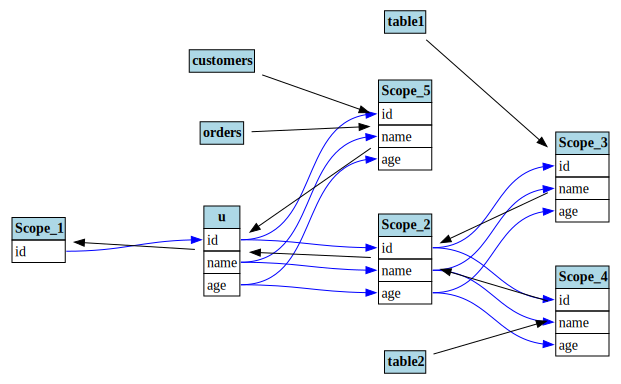

In [2]:
from sqlglot.optimizer.scope import build_scope
from sqlglot import parse_one
from sqlglot.optimizer.qualify import qualify
from sqlglot.lineage import lineage, GraphHTML
from sqlglot import exp
from lineage import LineageMap
from logging import basicConfig, DEBUG, getLogger

import sys
import logging

SQL_UNION =  """
SELECT u.id
    FROM (
    SELECT id, name, age
    FROM table1
    UNION ALL
    SELECT id, name, age
    FROM table2
    UNION ALL
    SELECT o.id, o.name, o.age
        FROM orders o
            INNER JOIN customers c ON o.customer_id = c.id) u


"""

sql_create1 = """
CREATE TABLE table1 (id INT, name VARCHAR(255), age INT);
"""
sql_create2 = """

"""


lin = LineageMap()
lin.parse_sql(SQL_UNION)
lin.visualize()

# lin.start_node.scope.expression

In [1]:
for col in lin.table_node_map["Scope_2"].columns.values():
    print(col.index)

NameError: name 'lin' is not defined

In [ ]:
lin.table_node_map["Scope_2"].scope.union_scopes

In [ ]:
sql_orders = """
CREATE TABLE orders (id INT, name Char, age INT );

"""
lin.extend_table("orders", sql_orders)

In [ ]:
schema = """SELECT name
FROM db1.cus.customer
"""

schema2 = """
SELECT Name
FROM db1.cus.customer
"""

ast1 = qualify(parse_one(schema))
ast2 = qualify(parse_one(schema2))

ast1==ast2

In [ ]:
lin.table_node_map["Scope_1"].scope.expression.selects

In [ ]:
lin.table_node_map["Scope_1"].scope.union_scopes

In [ ]:
sql_union = """
SELECT id, name, age
FROM table1
UNION ALL
SELECT id1, name, age
FROM table2
"""
ast = qualify(parse_one(sql_union))
scope = build_scope(ast)

In [ ]:
scope.union_scopes[0].sources

In [ ]:
scope.union_scopes